# Exploratory Data Analysis — Variation

This notebook covers **variation**: how the values of a single variable spread out.
Covariation (relationships between variables) is in `06_eda_covariation.ipynb`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # https://seaborn.pydata.org/

sns.set_theme()

FLIGHTS_URL = (
    "https://vincentarelbundock.github.io/Rdatasets/csv/nycflights13/flights.csv"
)

diamonds = sns.load_dataset("diamonds")
flights = pd.read_csv(FLIGHTS_URL).drop(columns="rownames")
smaller = diamonds[diamonds["carat"] < 3]


## Introduction

Exploratory data analysis (EDA) is an iterative cycle:

1. Generate questions about your data.
2. Search for answers by visualizing, transforming, and modelling.
3. Use what you learn to refine your questions and/or generate new questions.

EDA is not a formal process with a strict set of rules — it is a state of mind.
During early EDA you should feel free to investigate every idea.
Some ideas pan out; some are dead ends.

EDA is important even when research questions are handed to you:

- You always need to investigate data quality.
- Data cleaning is one application of EDA.
- Cleaning uses visualization, transformation, and modelling.


### Prerequisites

We combine **pandas** for transformations and **seaborn** for plots to ask questions and answer them with data.


## Questions

> "There are no routine statistical questions, only questionable statistical routines." — Sir David Cox

> "Far better an approximate answer to the right question, which is often vague, than an exact answer to the wrong question, which can always be made precise." — John Tukey

Use questions as tools to guide your investigation.
Each question focuses attention on part of the dataset and suggests which graphs or transforms to try.

Two question types are especially useful:

1. What type of **variation** occurs within my variables?
2. What type of **covariation** occurs between my variables?

This notebook focuses on variation.


## Variation

**Variation** is the tendency of values to change from measurement to measurement.

- Measuring the same quantity twice rarely gives identical results.
- Variables also vary across subjects or over time.

The best way to understand a variable's pattern is to visualize its **distribution**.

We start with the `carat` weights of ~54,000 diamonds.


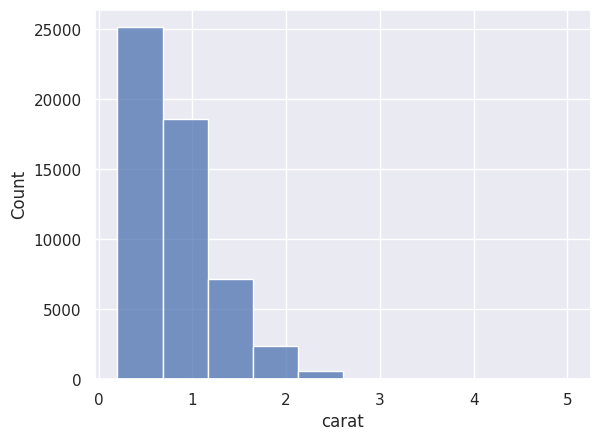

In [2]:
# Numerical variable → histogram
ax = sns.histplot(
    data=diamonds,
    x="carat",
    binwidth=0.5,  # each bar spans 0.5 carats
)


In histograms, tall bars show common values and short bars show rare ones.
Gaps show values that never appeared.

Ask follow-up questions using curiosity and skepticism:

- Which values are most common? Why?
- Which values are rare? Why? Does that match expectations?
- Any unusual patterns? What might explain them?


### Typical values

Let's zoom in on smaller diamonds (`carat` < 3).


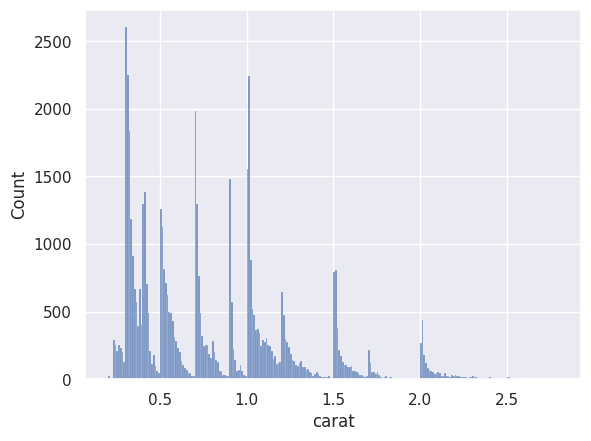

In [3]:
smaller = diamonds[diamonds['carat'] < 3]

ax = sns.histplot(
    data=smaller,
    x="carat",
    binwidth=0.01,  # narrow bins reveal peaks at common fractions
)


This histogram suggests questions such as:

- Why are there more diamonds at whole carats and common fractions?
- Why are there slightly more diamonds just to the right of each peak?

Clusters may suggest subgroups. Ask:

- How are observations within a cluster similar?
- How do separate clusters differ?
- How can you explain the clusters?
- Why might clusters be misleading?


### Unusual values

Outliers are observations that do not fit the main pattern.
With many points, outliers hide in histograms — only the wide x-axis on `y` hints at them.


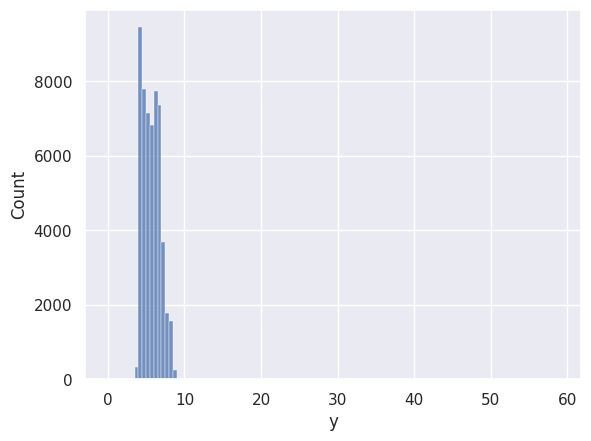

In [4]:
ax = sns.histplot(data=diamonds, x="y", binwidth=0.5)


Rare bins are too short to see. Zoom the y-axis instead of discarding data:


(0.0, 50.0)

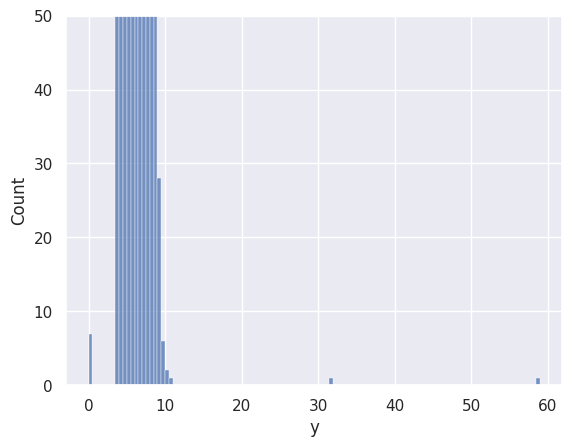

In [5]:
ax = sns.histplot(data=diamonds, x="y", binwidth=0.5)
ax.set_ylim(0, 50)  # magnify the short bars


We can now spot unusual values near 0, ~30, and ~60. Pull them out with pandas:


In [6]:
unusual = (
    diamonds.loc[(diamonds['y'] < 3) | (diamonds['y'] > 20), ['price', 'x', 'y', 'z']]
    .sort_values('y')
)
unusual


,price,x,y,z
11963,5139,0.00,0.0,0.00
15951,6381,0.00,0.0,0.00
24520,12800,0.00,0.0,0.00
26243,15686,0.00,0.0,0.00
49556,2130,0.00,0.0,0.00
27429,18034,0.00,0.0,0.00
49557,2130,0.00,0.0,0.00
49189,2075,5.15,31.8,5.12
24067,12210,8.09,58.9,8.06


`y` is one dimension of the diamond in mm.

- A width of 0 mm is impossible — likely missing data coded as 0.
- Very large `y` with moderate `price` may also be implausible.

Repeat analyses with and without outliers.
Drop them only when impact is small or you can justify the removal.


## Handling unusual values

Two options when you want to move on:

1. **Drop entire rows** — not recommended; one bad field does not invalidate the whole row.
2. **Replace unusual values with `NaN`** — keeps other columns for that observation.


In [7]:
# Option 1 (usually avoid): keep only plausible y
# diamonds_filtered = diamonds[diamonds['y'].between(3, 20)]

# Option 2 (recommended): mark implausible y as missing
diamonds2 = diamonds.copy()
diamonds2['y'] = diamonds2['y'].where(
    diamonds2['y'].between(3, 20),
    np.nan,
)


Missing points are dropped from the scatterplot by default.
To plot only complete pairs, drop rows with missing `x` or `y` first:


<Axes: xlabel='x', ylabel='y'>

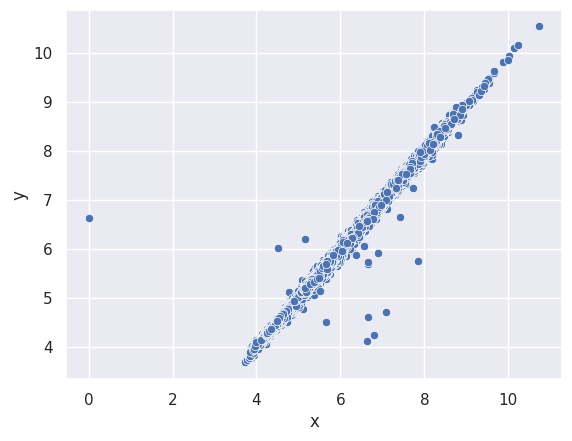

In [8]:
sns.scatterplot(data=diamonds2, x="x", y="y")


<Axes: xlabel='x', ylabel='y'>

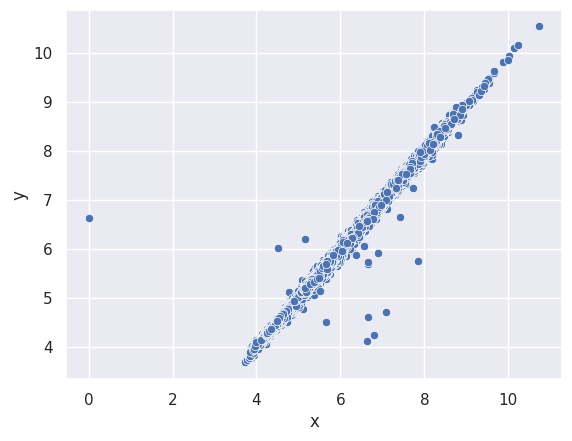

In [9]:
diamonds2_complete = diamonds2.dropna(subset=['x', 'y'])
sns.scatterplot(data=diamonds2_complete, x="x", y="y")


Sometimes missingness itself is informative.
In NYC flights data, missing `dep_time` means the flight was **cancelled**.


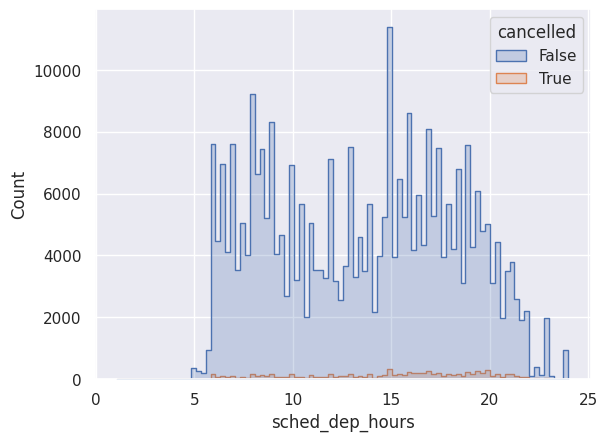

In [10]:
flights = flights.copy()
flights['cancelled'] = flights['dep_time'].isna()
flights['sched_hour'] = flights['sched_dep_time'] // 100
flights['sched_min'] = flights['sched_dep_time'] % 100
flights['sched_dep_hours'] = flights['sched_hour'] + flights['sched_min'] / 60

ax = sns.histplot(
    data=flights,
    x="sched_dep_hours",
    hue="cancelled",
    binwidth=0.25,
    element="step",  # overlaid frequency polygons
    common_norm=False,
)


Non-cancelled flights dominate the counts, so the shapes are hard to compare.
The covariation notebook shows ways to improve this comparison.

---

**Practice:** work through `exset_1/01_variation_exercises.ipynb`.
